In [1]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo

In [2]:
# Suppress all warnings
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

## Weather Data DMI

In [3]:
import dmi_open_data
dir(dmi_open_data)

['ClimateDataParameter',
 'DMIOpenDataClient',
 'OceanographicDataParameter',
 'Parameter',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'client',
 'date2microseconds',
 'enums',
 'microseconds2date',
 'utils']

In [4]:
from dmi_open_data import DMIOpenDataClient

## API ket for Climate Data

"climateDataAPI"

b555bb44-fd58-40d3-afdf-731fc7ddc5e2

In [5]:
import requests
import pandas as pd

api_key = "b555bb44-fd58-40d3-afdf-731fc7ddc5e2"
collections_url = "https://dmigw.govcloud.dk/v2/climateData/collections"

response = requests.get(collections_url, headers={"X-Gravitee-Api-Key": api_key})

if response.status_code == 200:
    collections = response.json().get("links", [])
    collections_df = pd.DataFrame(collections)
    print(collections_df)
else:
    print("Error:", response.status_code, response.text)


                                                href          rel  \
0  https://dmigw.govcloud.dk/v2/climateData/colle...         self   
1  https://opendatadocs.dmi.govcloud.dk/en/Terms_...      license   
2  https://www.geodata-info.dk/srv/dan/csw?servic...  describedby   
3  https://geodata-info.dk/srv/dan/catalog.search...  describedby   

               type                                 title  
0  application/json                         This document  
1  application/html  License for the data in this service  
2   application/xml      Metadata record for the data set  
3  application/html      Metadata record for the data set  


In [10]:
#features

Junget is he closest Station -> to Greenlav Skive

Junget   [9.0946, 56.7637]

In [11]:
#stations_df

In [9]:
import pandas as pd
import requests
from geopy.distance import geodesic
from datetime import datetime, timedelta

# -----------------------------
# 0️⃣ Setup
# -----------------------------
api_key = "b555bb44-fd58-40d3-afdf-731fc7ddc5e2"
headers = {"X-Gravitee-Api-Key": api_key}

stations_url = "https://dmigw.govcloud.dk/v2/climateData/collections/station/items"
values_url   = "https://dmigw.govcloud.dk/v2/climateData/collections/stationValue/items"

# -----------------------------
# 1️⃣ Fetch stations
# -----------------------------
resp_st = requests.get(stations_url, headers=headers)
resp_st.raise_for_status()
stations = resp_st.json().get("features", [])
stations_df = pd.json_normalize(stations)

stations_df = stations_df.rename(columns={
    "properties.stationId": "stationId",
    "properties.name": "stationName",
    "properties.parameterId": "parameters",
    "properties.country": "country",
    "properties.stationHeight": "height",
    "properties.type": "stationType",
    "properties.status": "status",
    "properties.operationFrom": "operationFrom",
    "properties.operationTo": "operationTo",
    "geometry.coordinates": "coordinates"
})

# -----------------------------
# 2️⃣ Filter stations with temperature data
# -----------------------------
temp_stations = stations_df[stations_df['parameters'].apply(lambda x: any('temp' in p.lower() for p in x))]

# -----------------------------
# 3️⃣ Find closest station to Skive
# -----------------------------
skive_coords = (56.5667, 9.0333)  # (lat, lon)

def distance_to_skive(coords):
    return geodesic((coords[1], coords[0]), skive_coords).km  # API coords: [lon, lat]

temp_stations['distance_km'] = temp_stations['coordinates'].apply(distance_to_skive)
closest_station = temp_stations.sort_values('distance_km').iloc[0]

station_id = closest_station['stationId']
parameter_id = [p for p in closest_station['parameters'] if 'temp' in p.lower()][0]

print(f"Using station {closest_station['stationName']} ({station_id}) with parameter {parameter_id}")

# -----------------------------
# 4️⃣ Fetch all hourly temperature data for a year
# -----------------------------
from_date = datetime(2018,1,1)
to_date   = datetime(2018,12,31,23)

all_data = []
chunk_days = 1000  # split into 30-day chunks to stay under 5000 limit
current_start = from_date

while current_start <= to_date:
    current_end = min(current_start + timedelta(days=chunk_days-1, hours=23), to_date)
    
    params = {
        "stationId": station_id,
        "parameterId": parameter_id,
        "datetime": f"{current_start.isoformat()}+00:00/{current_end.isoformat()}+00:00",
        "limit": 8760
    }
    
    resp = requests.get(values_url, headers=headers, params=params)
    resp.raise_for_status()
    features = resp.json().get("features", [])
    all_data.extend(features)
    
    current_start = current_end + timedelta(hours=1)

# -----------------------------
# 5️⃣ Build DataFrame
# -----------------------------
df_temp = pd.json_normalize(all_data)
df_temp = df_temp[["properties.from","properties.to","properties.value"]]
df_temp.columns = ["time_from","time_to","temperature"]

# Fix missing timestamps
df_temp['time'] = df_temp['time_from'].combine_first(df_temp['time_to'])
df_temp = df_temp[['time','temperature']].sort_values('time')
df_temp['time'] = pd.to_datetime(df_temp['time'], errors='coerce', utc=True)

print("\nFull hourly temperature time series (first 10 rows):")
print(df_temp.head())
print(f"\nTotal records fetched: {len(df_temp)}")


Using station Mejrup (06056) with parameter max_temp_w_date

Full hourly temperature time series (first 10 rows):
                          time  temperature
8759 2018-01-16 03:00:00+00:00          1.0
8758 2018-01-16 04:00:00+00:00          1.9
8757 2018-01-16 05:00:00+00:00          2.1
8756 2018-01-16 06:00:00+00:00          2.1
8755 2018-01-16 07:00:00+00:00          2.2

Total records fetched: 8760


In [12]:
df_temp

,time,temperature
8759,2018-01-16 03:00:00+00:00,1.0
8758,2018-01-16 04:00:00+00:00,1.9
8757,2018-01-16 05:00:00+00:00,2.1
8756,2018-01-16 06:00:00+00:00,2.1
8755,2018-01-16 07:00:00+00:00,2.2
...,...,...
4,2018-12-31 22:00:00+00:00,8.0
0,2018-12-31 23:00:00+00:00,8.1
3,NaT,8.3
2,NaT,32.3


In [13]:
df_temp["temperature"].size

8760

In [14]:
10*np.ones(df_temp["temperature"].size)

array([10., 10., 10., ..., 10., 10., 10.])

<Axes: >

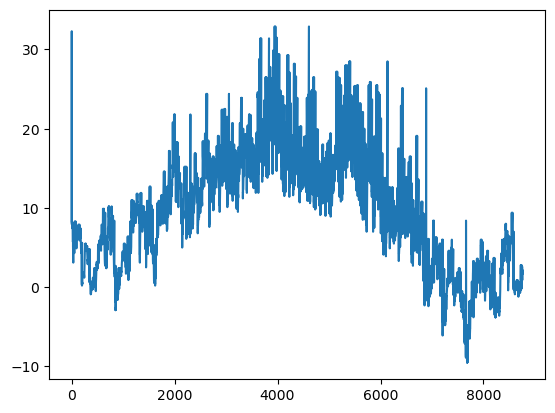

In [15]:
df_temp["temperature"].plot()

<Axes: >

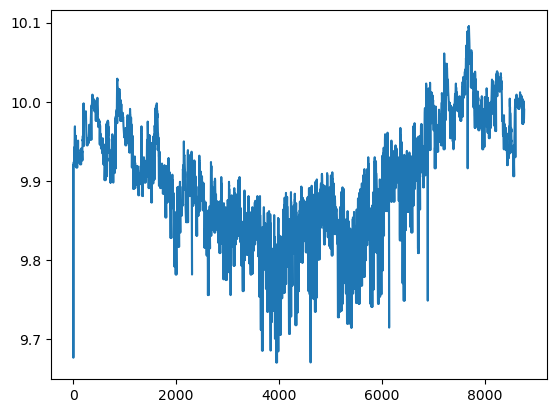

In [16]:
"Temprature of Rondo Bricks";
T_RONDO = 1000
U = 1e4          # W/K, heat loss coefficient of storage (example: 10 kW/K)
P_discharge = 0   # W, power discharged from storage (set to non-zero if used)
dt_hours = 1      # time step in hours

# Convert delta T to K (same as °C difference)
Q_loss_W = U * (T_RONDO*np.ones(df_temp["temperature"].size) - df_temp["temperature"])

E_input_J = (Q_loss_W + P_discharge)* dt_hours*3600 # 1 h = 3600s

# Convert to MWh
E_input_MWh = E_input_J/3.6e9

E_input_MWh.plot()

### Cost DataBase

In [17]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [18]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

In [19]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

## Load Data

In [20]:
# Get the directory of the current script
current_dir = os.getcwd()

# Build file paths relative to the script location
pv_file = os.path.join(current_dir, "pv_optimal.csv")
wind_file = os.path.join(current_dir, "onshore_wind_1979-2017.csv")
dk1_file = os.path.join(current_dir, "2017_DK1_SpotSprice_Load.xlsx")
# dk1_file = os.path.join(current_dir, "DK1_2017.csv")  # optional alternative

# Read the files
solar_pv_data = pd.read_csv(pv_file, sep=";")
onshore_wind_data = pd.read_csv(wind_file, sep=";")
DK1_data_2017 = pd.read_excel(dk1_file)

In [21]:
solar_pv_data['utc_time'] = pd.to_datetime(solar_pv_data['utc_time']).dt.tz_localize(None)
solar_pv_data.index = pd.DatetimeIndex(solar_pv_data['utc_time'])

onshore_wind_data['utc_time'] = pd.to_datetime(onshore_wind_data['utc_time']).dt.tz_localize(None)
onshore_wind_data.index = pd.DatetimeIndex(onshore_wind_data['utc_time'])

DK1_data_2017["HourUTC"] = pd.to_datetime(DK1_data_2017["HourUTC"], format="%d-%m-%Y %H:%M").dt.tz_localize(None)
DK1_data_2017.index = pd.DatetimeIndex(DK1_data_2017["HourUTC"])

In [22]:
DK1_data_2017.index.max()

Timestamp('2017-12-30 22:00:00')

In [23]:
"Time Period in which our model is running";

hours_in_2017 = pd.date_range('2017-01-01 00:00Z',
                              '2017-12-30 22:00Z',
                              freq='h')

hours_in_2017 = hours_in_2017.tz_localize(None)

print(DK1_data_2017.index.tz)

None


In [24]:
def add_carriers():
    n.add("Carrier", "gas", co2_emissions=0.19) # in t_CO2/MWh_th
    n.add("Carrier", "onshorewind")
    n.add("Carrier", "offshorewind")
    n.add("Carrier", "nuclear")
    n.add("Carrier","solar")
    n.add("Carrier","heat")
    n.add("Carrier","heat pump")
    n.add("Carrier", "electricity")  # Add electricity carrier
    n.add("Carrier", "battery storage")  # Add battery storage carrier
    n.add("Carrier","electric boiler")


In [25]:
def add_skive_generators():

    n.add("Generator", "Skive_Solar", carrier="solar",
        bus ="B1" ,
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu=solar_pv_data["DNK"].reindex(hours_in_2017).values, 
        p_nom = 36)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "B1",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu=onshore_wind_data["DNK"].reindex(hours_in_2017).values,
        p_nom = 54)

In [26]:
def add_battery(P_nom, max_t, cyclic_operation = True):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="B1",  # Use your electricity bus name
        carrier="battery storage",
        max_hours= max_t,  # 22 MW * 4 h = 88 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"]
            + 4 * costs.at["battery storage", "capital_cost"],
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # DIscharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

In [27]:
def add_TES_rondo(e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        e_nom= e_nom_store, # MWh
        e_nom_extendable=False,
        e_initial=0,
        e_cyclic=True,
        standing_loss= 1.2/100) # 1.2% per hour

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="B1",
        bus1="TES_Rondo",
        p_nom_extendable=False,
        p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "electricity",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_Bus_Skive",
        p_nom = p_nom_discharge,
        p_nom_extendable=False,
        efficiency=0.90,
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])

In [28]:
def  add_heat_load_boiler():
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "B1",
        bus1="Heat_Bus_Skive",
        p_nom = 10, # MW
        efficiency=0.9,
        carrier = "electric boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"])

    n.add("Load", "Skive_Heat_Load", 
        bus="Heat_Bus_Skive",
        p_nom_extendable=False,
        carrier = "heat",
        p_set = 5) # MWh

In [29]:
tariffs = {
    "consumers": {
        "transmission_grid_tariff": 8.2,  # €/MWh
        "reduced_transmission_tariff": 7.5,
        "limited_grid_access_tariff": 3.5,
        "system_tariff": 9.9,
        "system_tariff_above_100GWh": 0.099,
        "system_subscription": 24.4  # €/year
    },
    "producers": {
        "feed_in_tariff": 0.67,  # €/MWh delivered to grid
        "balance_tariff": 0.87
    },
    "BRP": {
        "balancing_fee": 0.13,  # €/MWh imbalance
        "weekly_fee": 30  # €/week
    }
}

# Example of accessing a value
print(tariffs["consumers"]["system_tariff"])  # Output: 9.9


9.9


In [30]:
p_import = tariffs["consumers"]["transmission_grid_tariff"]
p_export = tariffs["producers"]["feed_in_tariff"]

def add_grid(p_import, p_export):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
            bus="Grid_Import",
            p_nom_extendable = True,
            efficiency=1.0,
            marginal_cost=0,
            capital_cost=0.0)
    
    n.add("Link", "Imports",
            bus0="Grid_Import",
            bus1="B1",
    #        p_nom = 10,
            p_nom_extendable=True,
            efficiency=0.97,
            p_max_pu=1.0,
            carrier="electricity",
            marginal_cost=DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).values + p_import)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          efficiency_store=1.0,
          carrier="electricity",
          capital_cost=0.0,
          standing_loss=0.0)

    n.add("Link", "Exports",
            bus0="B1",
            bus1="Grid_Export",
        #   p_nom = 10, 
            p_nom_extendable=True,
            efficiency=0.97,
            p_min_pu=0,
            p_max_pu=1.0,
            carrier="electricity",
            marginal_cost= -DK1_data_2017["DK1_EUR/MWh"].reindex(hours_in_2017).values + p_export)

In [31]:
def add_el_load(p_el = 2):
    "Adding the Localised Demand in Greenlab Skive";
    n.add("Load", "Skive_el_Load", 
      bus="B1", 
      p_set= p_el) #MWh


### Simple Model

In [32]:
[p_import,p_export]

[8.2, 0.67]

In [33]:
n = pypsa.Network()

n.set_snapshots(hours_in_2017)

add_carriers()

n.add("Bus", "B1", carrier="electricity")
add_skive_generators()
add_battery(P_nom = 4, max_t = 4, cyclic_operation = True)

add_el_load(p_el = 2)


n.add("Bus", "Heat_Bus_Skive", carrier="heat")
add_heat_load_boiler()

n.add("Bus", "TES_Rondo", carrier="heat")
add_TES_rondo(e_nom_store = 100, p_nom_charge = 24,p_nom_discharge = 7)


n.add("Bus","Grid_Import", carrier = "electricity")
n.add("Bus","Grid_Export", carrier = "electricity")

add_grid(p_import = p_import ,p_export = p_export)

In [34]:
n.consistency_check()

In [35]:
# Check for missing buses
print("=== Buses ===")
print(n.buses.index.tolist())

print("\n=== Links (bus0 -> bus1) ===")
print(n.links[["bus0", "bus1"]])

print("\n=== Generators (bus) ===")
print(n.generators[["bus"]])

print("\n=== Loads (bus) ===")
print(n.loads[["bus"]])

print("\n=== Storage Units (bus) ===")
print(n.storage_units[["bus"]])

# Check for NaN in time-series
print("\n=== NaN counts in time series ===")
for col in n.generators_t.p_max_pu.columns:
    nan_count = n.generators_t.p_max_pu[col].isna().sum()
    if nan_count > 0:
        print(f"  {col}: {nan_count} NaN values")

print("\n=== Running consistency check ===")
n.consistency_check()

=== Buses ===
['B1', 'Heat_Bus_Skive', 'TES_Rondo', 'Grid_Import', 'Grid_Export']

=== Links (bus0 -> bus1) ===
                                    bus0            bus1
Link                                                    
Boiler_Skive                          B1  Heat_Bus_Skive
El_to_TES_Rondo                       B1       TES_Rondo
TES_Rondo_to_Heat_Bus_Skive    TES_Rondo  Heat_Bus_Skive
Imports                      Grid_Import              B1
Exports                               B1     Grid_Export

=== Generators (bus) ===
                            bus
Generator                      
Skive_Solar                  B1
Skive_Onshore_Wind           B1
Grid_Generator      Grid_Import

=== Loads (bus) ===
                            bus
Load                           
Skive_el_Load                B1
Skive_Heat_Load  Heat_Bus_Skive

=== Storage Units (bus) ===
              bus
StorageUnit      
Skive_Battery  B1

=== NaN counts in time series ===

=== Running consistency check ===


In [36]:
n.optimize(solver_name="gurobi")

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 20.66it/s]
INFO:linopy.io: Writing time: 3.02s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2602524


INFO:gurobipy:Set parameter LicenseID to value 2602524


...

Solved in 45166 iterations and 2.98 seconds (0.53 work units)


INFO:gurobipy:Solved in 45166 iterations and 2.98 seconds (0.53 work units)


Optimal objective -2.326758278e+06


INFO:gurobipy:Optimal objective -2.326758278e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131029 primals, 296994 duals
Objective: -2.33e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

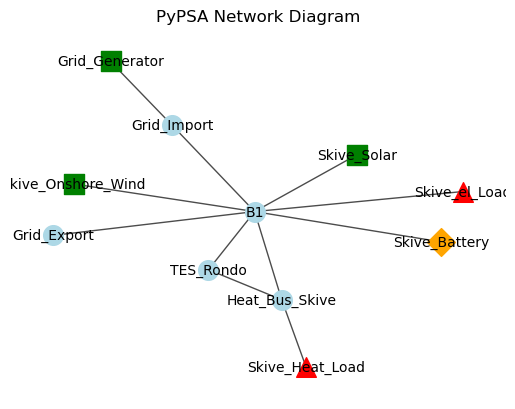

In [37]:
import networkx as nx
import matplotlib.pyplot as plt

# Start with buses and links
G = nx.Graph()

# Add buses
for bus_name in n.buses.index:
    G.add_node(bus_name, type="bus")

# Add links
for link_name, link in n.links.iterrows():
    G.add_edge(link.bus0, link.bus1, type="link", name=link_name)

# Add generators
for gen_name, gen in n.generators.iterrows():
    G.add_node(gen_name, type="generator")
    G.add_edge(gen.bus, gen_name, type="generator_connection")

# Add storage units
for su_name, su in n.storage_units.iterrows():
    G.add_node(su_name, type="storage")
    G.add_edge(su.bus, su_name, type="storage_connection")

# Add loads
for load_name, load in n.loads.iterrows():
    G.add_node(load_name, type="load")
    G.add_edge(load.bus, load_name, type="load_connection")

# Define positions (spring layout or use bus coordinates if available)
pos = nx.spring_layout(G, seed=10)
# Draw edges first
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.7)

# Draw nodes by type with different shapes
node_shapes = {
    "bus": ("o", "lightblue"),          # circle
    "generator": ("s", "green"),        # square
    "storage": ("D", "orange"),         # diamond
    "load": ("^", "red")                # triangle
}

for ntype, (shape, color) in node_shapes.items():
    nodes_of_type = [node for node, attr in G.nodes(data=True) if attr["type"] == ntype]
    nx.draw_networkx_nodes(G, pos,
                           nodelist=nodes_of_type,
                           node_color=color,
                           node_shape=shape,
                           node_size=200,
                           label=ntype.capitalize())

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10)

# Add legend
#plt.legend(scatterpoints=1)
plt.axis("off")
plt.title("PyPSA Network Diagram")
plt.show()

In [38]:
#conda install graphviz

In [63]:
import graphviz

In [40]:
# Draw the network
pypsatopo.generate(n)

[ERR] The tool 'dot' is not installed or could not be found (please visit https://graphviz.org/download to download and install it)!


-1

<Axes: xlabel='snapshot'>

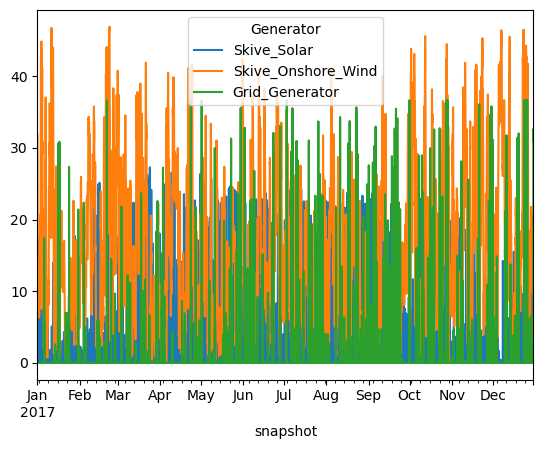

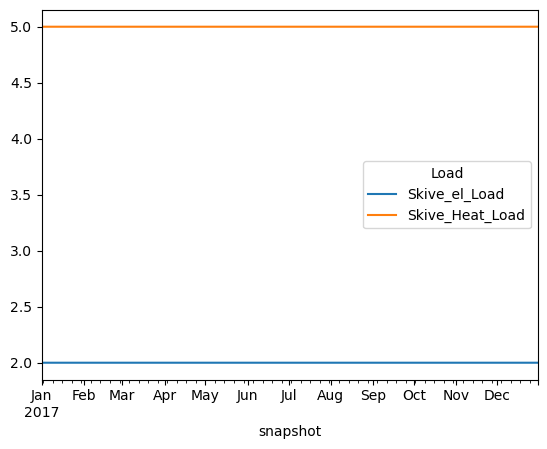

In [41]:
n.generators_t.p.plot()
n.loads_t.p.plot()

In [42]:
# Safe access with fallback
if "Skive_Battery" in n.storage_units_t.p_dispatch.columns:
    n.storage_units_t.p_dispatch["Skive_Battery"].head()
else:
    print("ERROR: 'Skive_Battery' results not found after optimization")
    print("Available storage units:", n.storage_units_t.p_dispatch.columns.tolist())

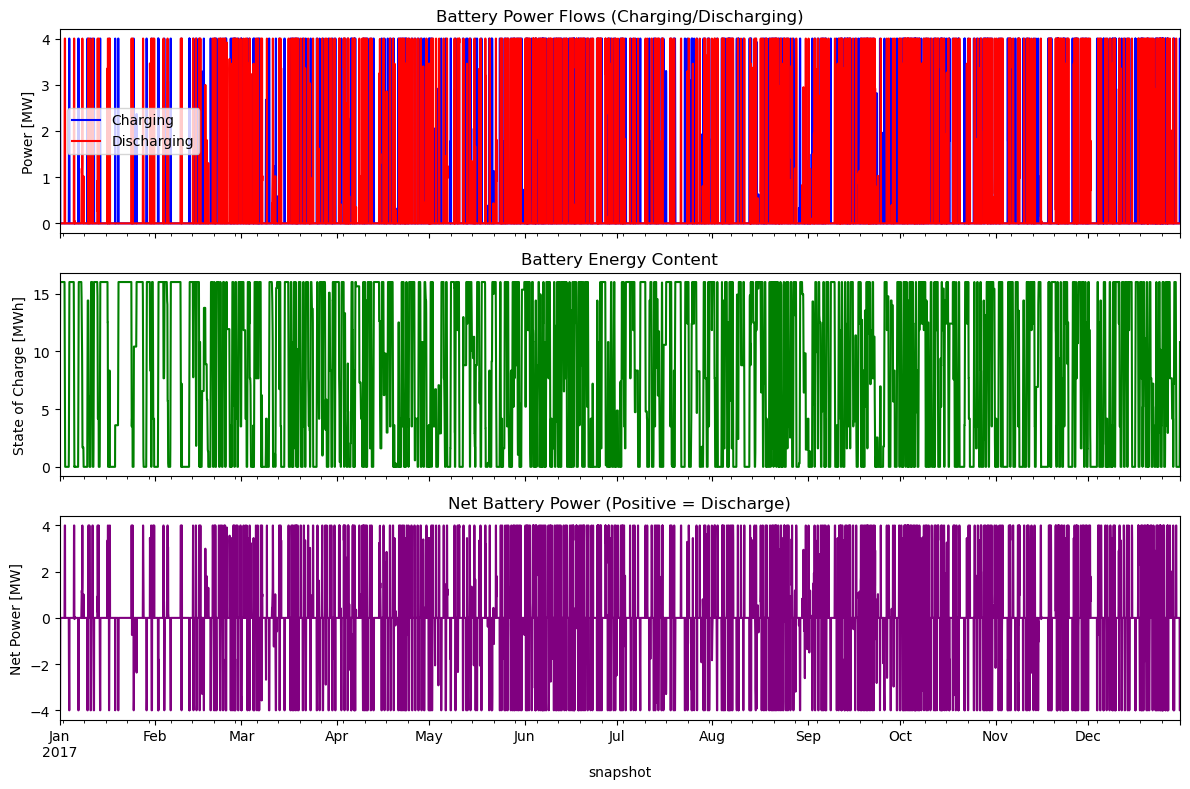

In [43]:
# Discharge power (positive when delivering electricity)
n.storage_units_t.p_dispatch["Skive_Battery"].head()

# Charging power (positive when charging)
n.storage_units_t.p_store["Skive_Battery"].head()

n.storage_units_t.state_of_charge["Skive_Battery"].head()


fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

n.storage_units_t.p_store["Skive_Battery"].plot(ax=ax[0], label="Charging", color="blue")
n.storage_units_t.p_dispatch["Skive_Battery"].plot(ax=ax[0], label="Discharging", color="red")
ax[0].set_ylabel("Power [MW]")
ax[0].legend()
ax[0].set_title("Battery Power Flows (Charging/Discharging)")

n.storage_units_t.state_of_charge["Skive_Battery"].plot(ax=ax[1], color="green")
ax[1].set_ylabel("State of Charge [MWh]")
ax[1].set_title("Battery Energy Content")

# Optional: plot net power (discharge - charge)
net_p = n.storage_units_t.p_dispatch["Skive_Battery"] - n.storage_units_t.p_store["Skive_Battery"]
net_p.plot(ax=ax[2], color="purple")
ax[2].set_ylabel("Net Power [MW]")
ax[2].set_title("Net Battery Power (Positive = Discharge)")

plt.tight_layout()
plt.show()


<Axes: xlabel='snapshot'>

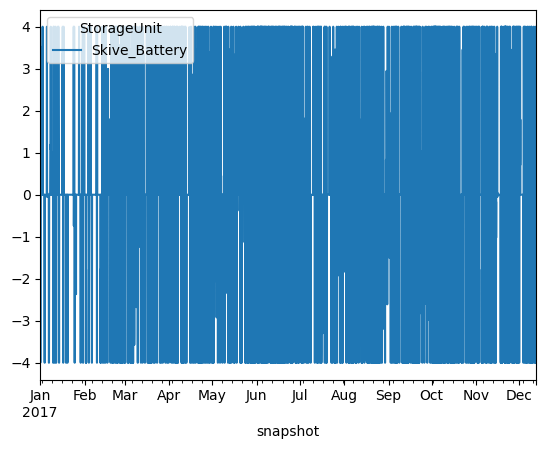

In [44]:
n.storage_units_t.p.loc["2017-01-01":"2017-12-12"].plot()

In [45]:

# align to network snapshots (fill missing with 0)
n.links_t.p0["Exports"].reindex(n.snapshots)

snapshot
2017-01-01 00:00:00    33.378257
2017-01-01 01:00:00    22.296000
2017-01-01 02:00:00     0.000000
2017-01-01 03:00:00     0.000000
2017-01-01 04:00:00     0.000000
                         ...    
2017-12-30 18:00:00     0.000000
2017-12-30 19:00:00     0.000000
2017-12-30 20:00:00     0.000000
2017-12-30 21:00:00     0.000000
2017-12-30 22:00:00     0.000000
Name: Exports, Length: 8735, dtype: float64

In [46]:
n.links_t.p0["Imports"].reindex(n.snapshots)

snapshot
2017-01-01 00:00:00     0.000000
2017-01-01 01:00:00     0.000000
2017-01-01 02:00:00     0.000000
2017-01-01 03:00:00     0.000000
2017-01-01 04:00:00     0.000000
                         ...    
2017-12-30 18:00:00     0.000000
2017-12-30 19:00:00     4.393356
2017-12-30 20:00:00    32.646964
2017-12-30 21:00:00    31.756243
2017-12-30 22:00:00    31.032532
Name: Imports, Length: 8735, dtype: float64

<Axes: xlabel='snapshot'>

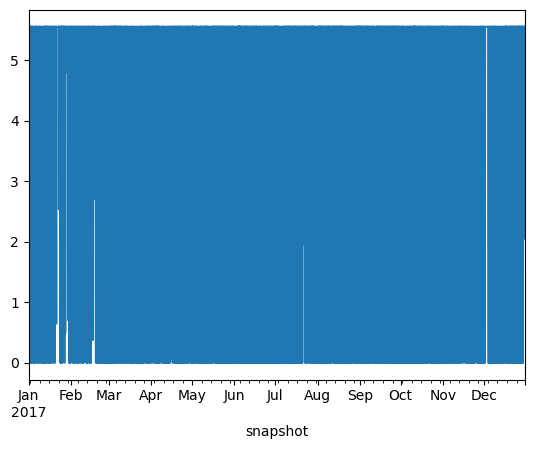

In [47]:
n.links_t.p0["Boiler_Skive"].reindex(n.snapshots).plot()

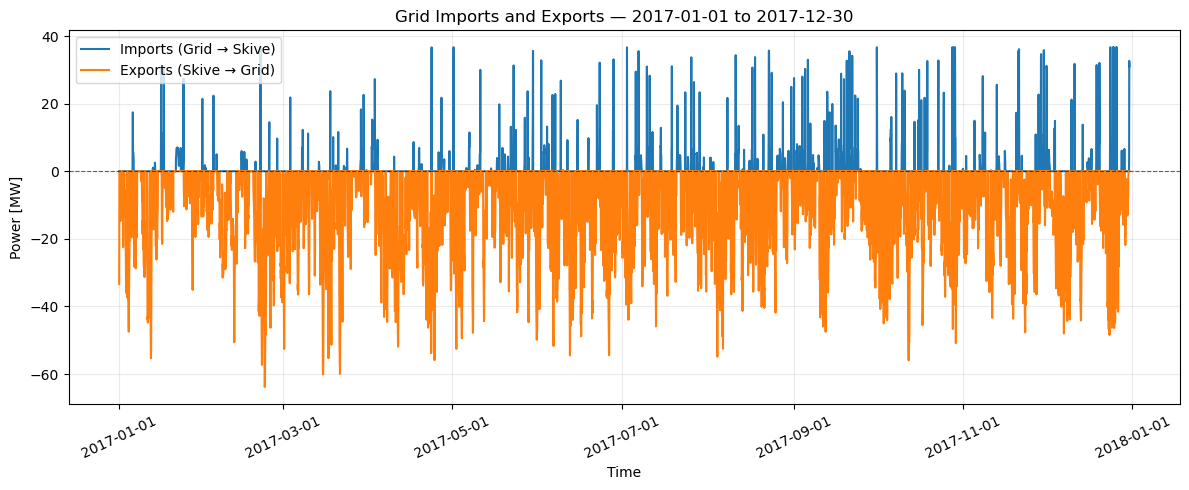

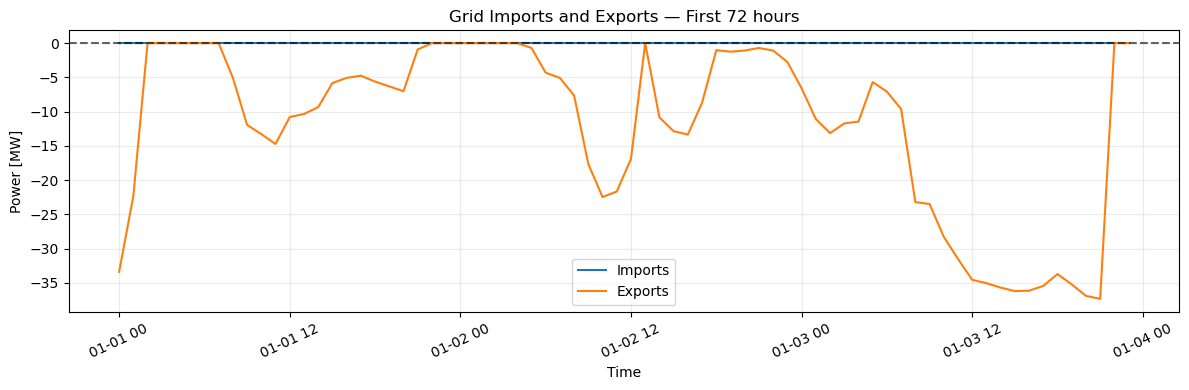

In [48]:
# ...existing code...
import matplotlib.dates as mdates

# align to network snapshots (fill missing with 0)
imports = n.links_t.p0["Imports"].reindex(n.snapshots)
exports = -n.links_t.p0["Exports"].reindex(n.snapshots)

# choose timeframe
start_date = "2017-01-01"
end_date   = "2017-12-30"

# full week plot
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(imports.loc[start_date:end_date].index, imports.loc[start_date:end_date].values,
        label="Imports (Grid → Skive)", color="#1f77b4", linewidth=1.5)
ax.plot(exports.loc[start_date:end_date].index, exports.loc[start_date:end_date].values,
        label="Exports (Skive → Grid)", color="#ff7f0e", linewidth=1.5)
ax.axhline(0, color="k", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_xlabel("Time")
ax.set_ylabel("Power [MW]")
ax.set_title(f"Grid Imports and Exports — {start_date} to {end_date}")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=25)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# zoom: first 72 hours
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(imports.iloc[0:24*3].index, imports.iloc[0:24*3].values, label="Imports", color="#1f77b4")
ax.plot(exports.iloc[0:24*3].index, exports.iloc[0:24*3].values, label="Exports", color="#ff7f0e")
ax.axhline(0, color="k", linestyle="--", alpha=0.6)
ax.set_xlabel("Time")
ax.set_ylabel("Power [MW]")
ax.set_title("Grid Imports and Exports — First 72 hours")
ax.legend()
plt.xticks(rotation=25)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

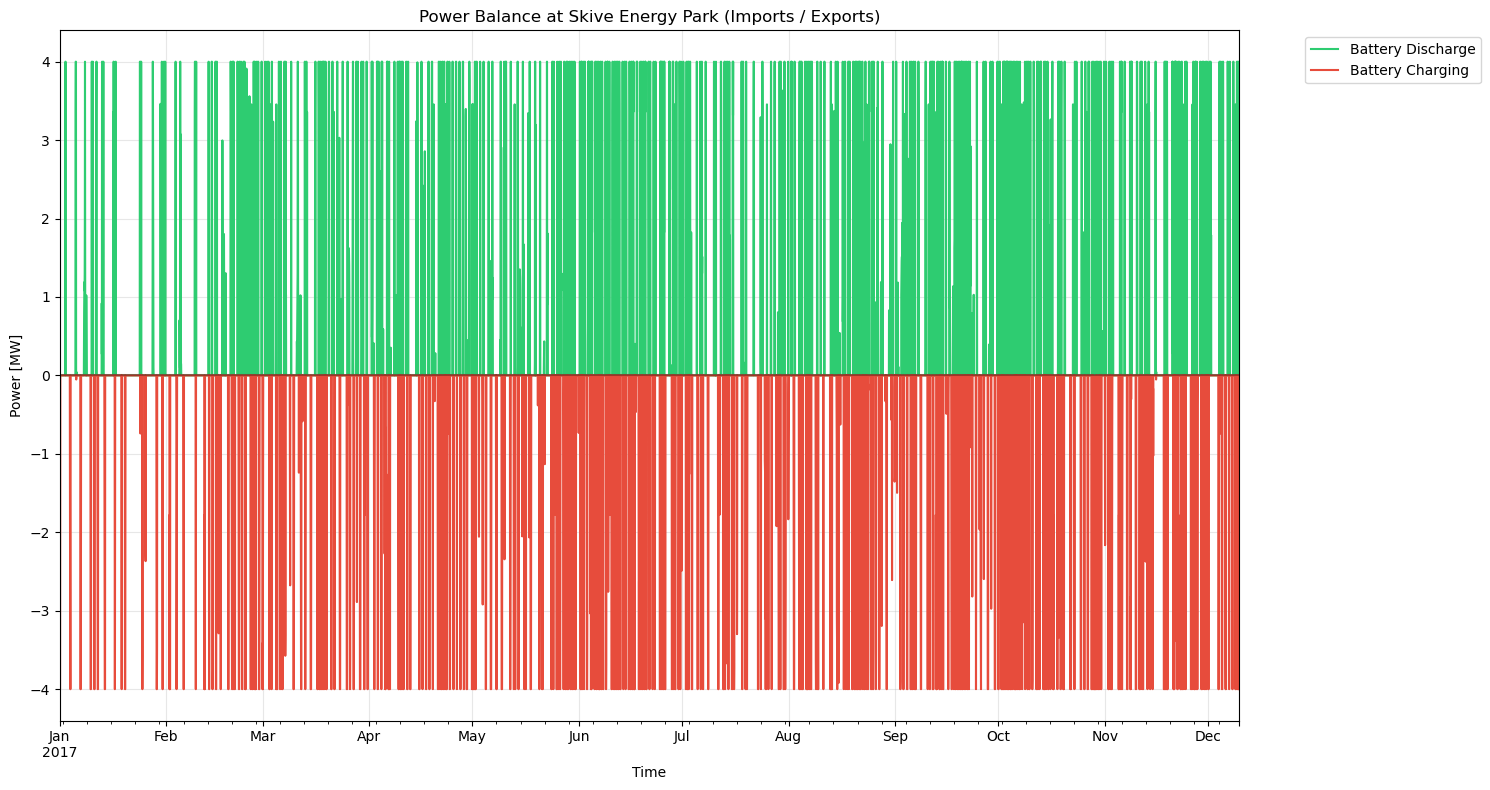

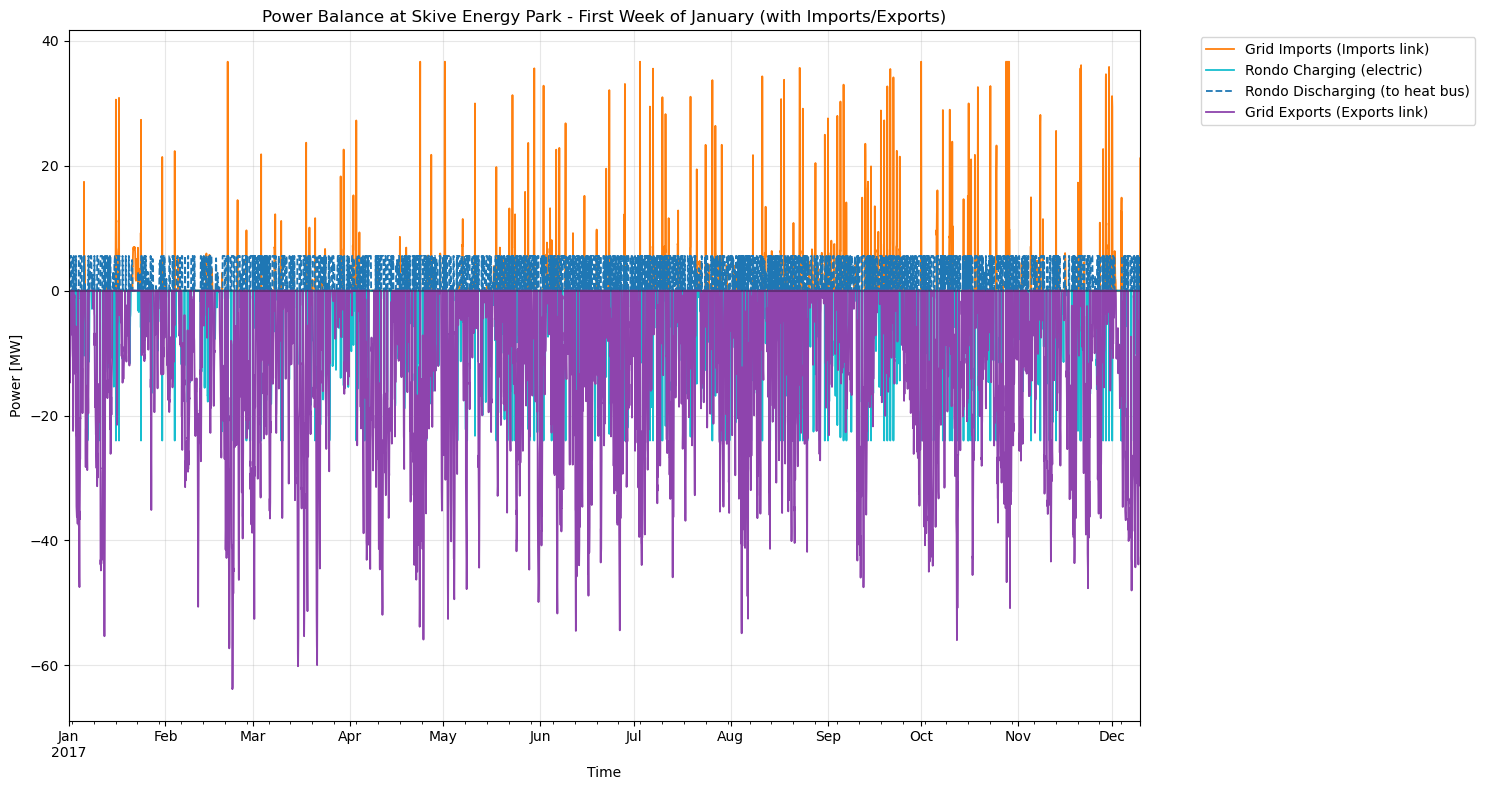

In [49]:
# ...existing code...
import matplotlib.dates as mdates

def safe_series(df, key):
    try:
        return df[key].reindex(n.snapshots).fillna(0)
    except Exception:
        return pd.Series(0.0, index=n.snapshots, name=key)

# read Imports/Exports (fall back to zero series if missing)
imports = safe_series(n.links_t.p0, "Imports")
exports = safe_series(n.links_t.p0, "Exports")

exports = -exports  # invert sign for exports to match convention

# positive import = grid -> B1, positive export = B1 -> grid
#imports_pos = imports.clip(lower=0)
#exports_pos = exports.clip(lower=0

start_date = '2017-01-01'
end_date = '2017-12-10'

# colors
col_grid_imp = '#FF7F0E'
col_grid_exp = '#8E44AD'

# Main plot
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# battery and rondo flows (existing)
n.storage_units_t.p_dispatch["Skive_Battery"].plot(ax=ax, label="Battery Discharge", color='#2ECC71', linewidth=1.5)
(-n.storage_units_t.p_store["Skive_Battery"]).plot(ax=ax, label="Battery Charging", color='#E74C3C', linewidth=1.5)

#(-n.links_t.p0.get("El_to_TES_Rondo", pd.Series(0, index=n.snapshots))).plot(ax=ax, label="Rondo Charging (electric)", color='#17BECF', linewidth=1.25)
#n.links_t.p0.get("TES_Rondo_to_Heat_Bus_Skive", pd.Series(0, index=n.snapshots)).plot(ax=ax, label="Rondo Discharging (to heat bus)", color='#1F77B4', linestyle='--', linewidth=1.25)

# plot Imports/Exports
#imports.plot(ax=ax, label="Imports (Imports link)", color=col_grid_imp, linewidth=1.3, alpha=0.9)
#exports.plot(ax=ax, label="Exports (Exports link)", color=col_grid_exp, linewidth=1.3, alpha=0.9)

ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Time')
ax.set_ylabel('Power [MW]')
ax.set_title('Power Balance at Skive Energy Park (Imports / Exports)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.xlim(start_date, end_date)
plt.show()

# Week view
plt.figure(figsize=(15, 8))

#n.generators_t.p["Skive_Solar"].loc[start_date:end_date].plot(label="Solar PV", color='#FFC300', linewidth=1.3)
#n.generators_t.p["Skive_Onshore_Wind"].loc[start_date:end_date].plot(label="Wind", color='#0057E7', linewidth=1.3)
#n.storage_units_t.p_dispatch["Skive_Battery"].loc[start_date:end_date].plot(label="Battery Discharge", color='#2ECC71', linewidth=1.3)
imports.loc[start_date:end_date].plot(label="Grid Imports (Imports link)", color=col_grid_imp, linewidth=1.3)
#(-n.links_t.p0.get("Boiler_Skive", pd.Series(0, index=n.snapshots)).loc[start_date:end_date]).plot(label="Electric Boiler", color='#7F8C8D', linewidth=1.3)
(-n.links_t.p0.get("El_to_TES_Rondo", pd.Series(0, index=n.snapshots)).loc[start_date:end_date]).plot(label="Rondo Charging (electric)", color='#17BECF', linewidth=1.3)
n.links_t.p0.get("TES_Rondo_to_Heat_Bus_Skive", pd.Series(0, index=n.snapshots)).loc[start_date:end_date].plot(label="Rondo Discharging (to heat bus)", color='#1F77B4', linestyle='--', linewidth=1.3)
#(-n.storage_units_t.p_store["Skive_Battery"].loc[start_date:end_date]).plot(label="Battery Charging", color='#E74C3C', linewidth=1.3)
exports.loc[start_date:end_date].plot(label="Grid Exports (Exports link)", color=col_grid_exp, linewidth=1.3)

plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.xlabel('Time')
plt.ylabel('Power [MW]')
plt.title('Power Balance at Skive Energy Park - First Week of January (with Imports/Exports)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(start_date, end_date)
plt.tight_layout()
plt.show()

In [50]:
"Optimal Generator Capacity (GW)";
n.generators.p_nom_opt # in GW

Generator
Skive_Solar           36.000000
Skive_Onshore_Wind    54.000000
Grid_Generator        36.655212
Name: p_nom_opt, dtype: float64

In [51]:
"Minimum cost of the system";
n.objective/1e9 # Bn of EUR annum

-0.0023267582783705423

In [52]:
n.stores.e_nom_opt

Store
Rondo_Concrete_Heat_Storage      100.000000
Grid_Store                     89447.532664
Name: e_nom_opt, dtype: float64

In [53]:
n.loads_t

{'p_set': Empty DataFrame
 Columns: []
 Index: [2017-01-01 00:00:00, 2017-01-01 01:00:00, 2017-01-01 02:00:00, 2017-01-01 03:00:00, 2017-01-01 04:00:00, 2017-01-01 05:00:00, 2017-01-01 06:00:00, 2017-01-01 07:00:00, 2017-01-01 08:00:00, 2017-01-01 09:00:00, 2017-01-01 10:00:00, 2017-01-01 11:00:00, 2017-01-01 12:00:00, 2017-01-01 13:00:00, 2017-01-01 14:00:00, 2017-01-01 15:00:00, 2017-01-01 16:00:00, 2017-01-01 17:00:00, 2017-01-01 18:00:00, 2017-01-01 19:00:00, 2017-01-01 20:00:00, 2017-01-01 21:00:00, 2017-01-01 22:00:00, 2017-01-01 23:00:00, 2017-01-02 00:00:00, 2017-01-02 01:00:00, 2017-01-02 02:00:00, 2017-01-02 03:00:00, 2017-01-02 04:00:00, 2017-01-02 05:00:00, 2017-01-02 06:00:00, 2017-01-02 07:00:00, 2017-01-02 08:00:00, 2017-01-02 09:00:00, 2017-01-02 10:00:00, 2017-01-02 11:00:00, 2017-01-02 12:00:00, 2017-01-02 13:00:00, 2017-01-02 14:00:00, 2017-01-02 15:00:00, 2017-01-02 16:00:00, 2017-01-02 17:00:00, 2017-01-02 18:00:00, 2017-01-02 19:00:00, 2017-01-02 20:00:00, 2017-01

Load names: ['Skive_el_Load', 'Skive_Heat_Load']

Static loads table:


,bus,carrier,type,p_set,q_set,sign,active,p_nom_extendable
Load,,,,,,,,
Skive_el_Load,B1,,,2.0,0.0,-1.0,True,NaN
Skive_Heat_Load,Heat_Bus_Skive,heat,,5.0,0.0,-1.0,True,False



Loads time-series columns: ['Skive_el_Load', 'Skive_Heat_Load']


Load,Skive_el_Load,Skive_Heat_Load
snapshot,,
2017-01-01 00:00:00,2.0,5.0
2017-01-01 01:00:00,2.0,5.0
2017-01-01 02:00:00,2.0,5.0
2017-01-01 03:00:00,2.0,5.0
2017-01-01 04:00:00,2.0,5.0


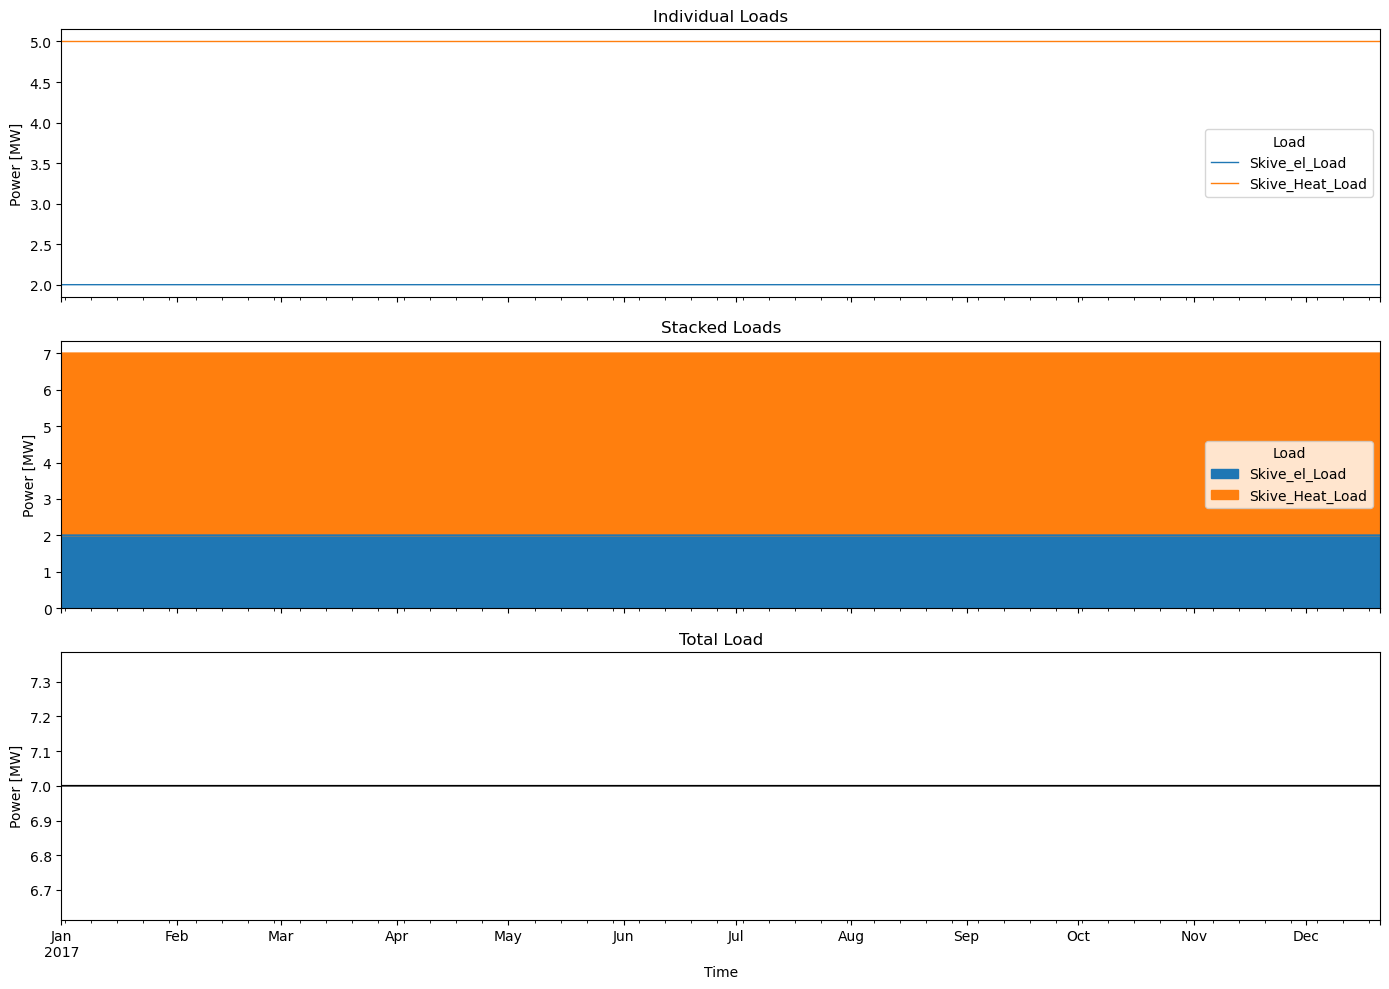

In [54]:
# ...existing code...
# Show loads and time-series
print("Load names:", n.loads.index.tolist())
print("\nStatic loads table:")
display(n.loads)

print("\nLoads time-series columns:", n.loads_t.p.columns.tolist())
display(n.loads_t.p.head())

# Plot individual loads, stacked loads and total load for a short period
import matplotlib.pyplot as plt
start = "2017-01-01"
end   = "2017-12-20"

fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 1) Individual loads
n.loads_t.p.loc[start:end].plot(ax=axs[0], linewidth=1)
axs[0].set_title("Individual Loads")
axs[0].set_ylabel("Power [MW]")

# 2) Stacked area of loads
n.loads_t.p.loc[start:end].plot.area(ax=axs[1])
axs[1].set_title("Stacked Loads")
axs[1].set_ylabel("Power [MW]")

# 3) Total system load
total_load = n.loads_t.p.sum(axis=1)
total_load.loc[start:end].plot(ax=axs[2], color="k", linewidth=1.25)
axs[2].set_title("Total Load")
axs[2].set_ylabel("Power [MW]")
axs[2].set_xlabel("Time")

plt.tight_layout()
plt.show()

<Axes: xlabel='snapshot'>

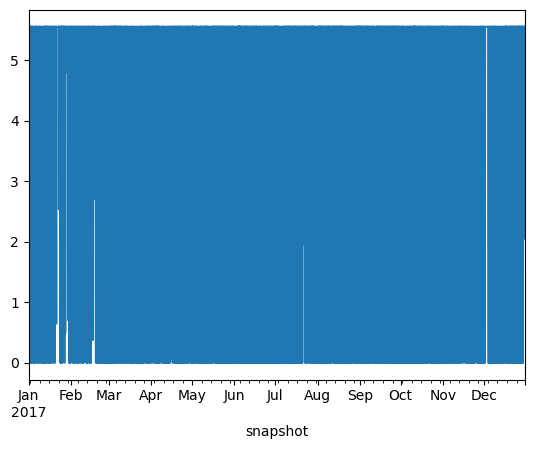

In [55]:
n.links_t.p0["Boiler_Skive"].reindex(n.snapshots).plot()

In [56]:
n.stores_t.p

Store,Rondo_Concrete_Heat_Storage,Grid_Store
snapshot,,
2017-01-01 00:00:00,5.555556,-32.376909
2017-01-01 01:00:00,5.555556,-21.627120
2017-01-01 02:00:00,-12.066196,0.000000
2017-01-01 03:00:00,-10.310198,0.000000
2017-01-01 04:00:00,-8.947836,0.000000
...,...,...
2017-12-30 18:00:00,3.505556,0.000000
2017-12-30 19:00:00,0.000000,0.000000
2017-12-30 20:00:00,-23.520000,0.000000


<Axes: xlabel='snapshot'>

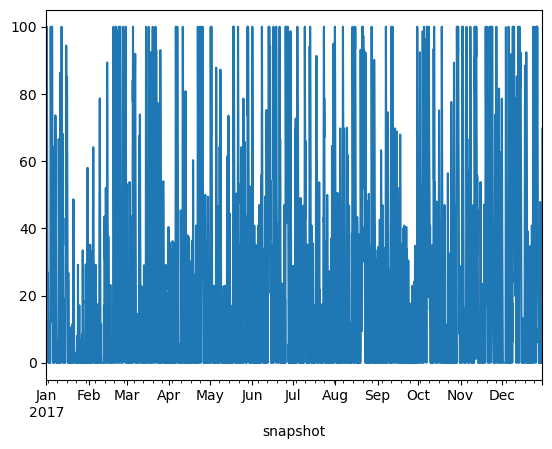

In [57]:
"Rondo Heat Energy Storage";
n.stores_t.e['Rondo_Concrete_Heat_Storage'].plot()

<Axes: xlabel='snapshot'>

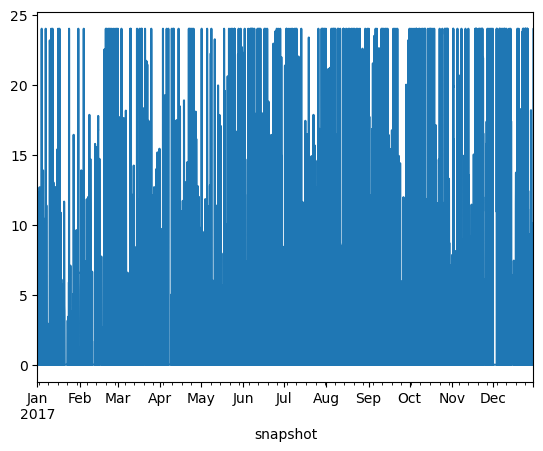

(412008.0, 412056.0)

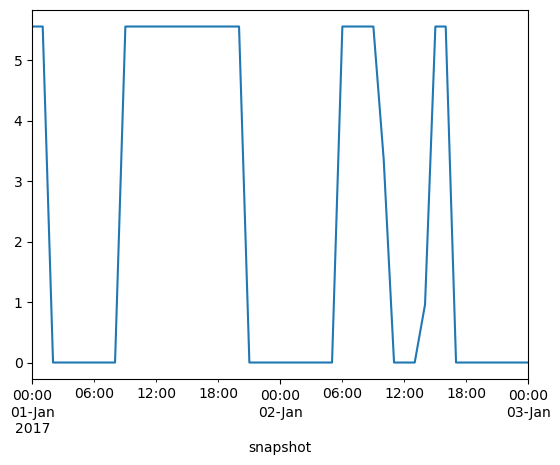

In [58]:
display(n.links_t.p0["El_to_TES_Rondo"].plot())
plt.show()
n.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"].plot()
plt.xlim('2017-01-01 00:00Z', '2017-01-03 00:00Z')